In [507]:
import math
import os
import csv
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

In [508]:
USER = 'shuyuan' ## kaiwen or tianshu
ROTAXIS = 'yaw' ## roll, pitch, yaw
TESTNUM = 5 ## kaiwen 1-5, tianshu 1-5
DIAMETER = 50 ## 50 or 80
data_dir = f'data/raw_data/{DIAMETER}mm/{USER}/{ROTAXIS}/test_{TESTNUM}'
save_dir = f'data/segmented_data/{DIAMETER}mm/{USER}/{ROTAXIS}'
os.makedirs(save_dir, exist_ok=True)
file_dir = f'{save_dir}/test_{TESTNUM}.csv'
if USER == 'kaiwen' and ROTAXIS == 'pitch' and TESTNUM == 1:
    zero_height = 0.01
elif USER == 'kaiwen' and ROTAXIS == 'pitch' and TESTNUM == 4:
    zero_height = 0.005
else:
    zero_height = 0.1

if USER == 'tianshu' and ROTAXIS == 'pitch' and TESTNUM == 1:
    zero_height = 0.01
if USER == 'tianshu' and ROTAXIS == 'pitch' and TESTNUM == 3:
    zero_height = 0.005

if USER == 'yizhou' and ROTAXIS == 'roll' and TESTNUM == 1:
    zero_height = 0.01
if USER == 'yizhou' and ROTAXIS == 'roll' and TESTNUM == 2:
    zero_height = 0.0001
if USER == 'yizhou' and ROTAXIS == 'roll' and TESTNUM == 3:
    zero_height = 0.001
if USER == 'yizhou' and ROTAXIS == 'pitch' and TESTNUM == 4:
    zero_height = 0.01

# Function Libs

In [509]:
def load_data(data_dir):
    raw_data = pd.read_csv(os.path.join(data_dir, 'raw_data.csv'), header=None).to_numpy().reshape(-1, 18)
    raw_data_force = np.concatenate((raw_data[:, 0:3],
                                     raw_data[:, 6:9],
                                     raw_data[:, 12:15]),axis=1)
    transformed_data = pd.read_csv(os.path.join(data_dir, 'transformed_data.csv'), header=None).to_numpy().reshape(-1, 18)
    transformed_data_force = np.concatenate((transformed_data[:, 0:3],
                                            transformed_data[:, 6:9],
                                            transformed_data[:, 12:15]),axis=1)
    return raw_data, raw_data_force, transformed_data_force

In [510]:
def pca_analysis(data, n_components=9, force_threshold=0.1):
    print(f"Before clipping, data samples: {data.shape[0]}")
    if n_components == 9:
        s1_force = data[:, 0:3]
        s2_force = data[:, 3:6]
        s3_force = data[:, 6:9]
        s1_norm_force = np.linalg.norm(s1_force, axis=1).reshape(-1, 1)
        s2_norm_force = np.linalg.norm(s2_force, axis=1).reshape(-1, 1)
        s3_norm_force = np.linalg.norm(s3_force, axis=1).reshape(-1, 1)
        mask_indexes = []
        for i in range(s1_norm_force.shape[0]):
            if s1_norm_force[i] < force_threshold and s2_norm_force[i] < force_threshold and s3_norm_force[i] < force_threshold:
                mask_indexes.append(i)
        data_filtered = np.delete(data, mask_indexes, axis=0)
    elif n_components == 18:
        s1_force = data[:, 0:3]
        s2_force = data[:, 6:9]
        s3_force = data[:, 12:15]
        s1_norm_force = np.linalg.norm(s1_force, axis=1).reshape(-1, 1)
        s2_norm_force = np.linalg.norm(s2_force, axis=1).reshape(-1, 1)
        s3_norm_force = np.linalg.norm(s3_force, axis=1).reshape(-1, 1)
        mask_indexes = []
        for i in range(s1_norm_force.shape[0]):
            if s1_norm_force[i] < force_threshold and s2_norm_force[i] < force_threshold and s3_norm_force[i] < force_threshold:
                mask_indexes.append(i)
        data_filtered = np.delete(data, mask_indexes, axis=0)
        scaler = StandardScaler()
        data_filtered = scaler.fit_transform(data_filtered)

    print(f"After clipping, data samples: {data_filtered.shape[0]}")

    pca = PCA(n_components=n_components)
    pca.fit_transform(data_filtered)
    return pca.components_, pca.explained_variance_, pca.explained_variance_ratio_

In [511]:
def plot_pca_heatmap_horizontal_forces(pca_components, eigenvalues, explained_variance_ratio, transformed: bool=False):

    # ==== Print PCA summary ====
    print("PC  | Eigenvalue | Variance Ratio")
    print("-" * 40)
    for i, (val, ratio) in enumerate(zip(eigenvalues, explained_variance_ratio)):
        print(f"PC{i+1:<3} | {val:<10.4f} | {ratio:.2%}")
    print("-" * 40)
    print(f"Sum of eigenvalues: {np.sum(eigenvalues):.4f}\n")

    # ==== Build DataFrame ====
    if transformed:
        axis_labels = ['Grav', 'Lateral', 'Normal'] * 3
    else:
        axis_labels = ['Fx', 'Fy', 'Fz'] * 3
    pc_names = [f'PC{i+1}' for i in range(pca_components.shape[0])]
    df = pd.DataFrame(pca_components.T, index=axis_labels, columns=pc_names)

    # ==== Plot ====
    plt.figure(figsize=(10, 10))

    ax = sns.heatmap(
        df,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.6,              # cell borders
        linecolor="gray",            # gray boudnary lines
        cbar_kws={"label": "Loading Weight"}
    )

    # seperate three fingers
    for y in [3, 6]:
        ax.axhline(y, color="black", lw=2, ls="-")

    # label the finger
    for y, label in zip([1.5, 4.5, 7.5], ["Thumb", "Ring", "Index"]):
        ax.text(-0.05, y, label,
                va="center", ha="right",
                rotation=90,
                transform=ax.get_yaxis_transform())

    # boundaries
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)

    plt.title(f'{ROTAXIS.capitalize()}, Test {TESTNUM}: PCA Loadings')
    plt.xlabel("Principal Components")
    plt.ylabel("Force Sensors", labelpad=20)
    plt.tight_layout()
    plt.show()

In [512]:
def plot_pca_heatmap_horizontal_ft(pca_components, eigenvalues, explained_variance_ratio):

    # ==== Print PCA summary ====
    print("PC  | Eigenvalue | Variance Ratio")
    print("-" * 40)
    for i, (val, ratio) in enumerate(zip(eigenvalues, explained_variance_ratio)):
        print(f"PC{i+1:<3} | {val:<10.4f} | {ratio:.2%}")
    print("-" * 40)
    print(f"Sum of eigenvalues: {np.sum(eigenvalues):.4f}\n")

    # ==== Build DataFrame ====
    axis_labels = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz'] * 3
    pc_names = [f'PC{i+1}' for i in range(pca_components.shape[0])]
    df = pd.DataFrame(pca_components.T, index=axis_labels, columns=pc_names)

    # ==== Plot ====
    plt.figure(figsize=(10, 10))

    ax = sns.heatmap(
        df,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        linewidths=0.6,              # cell borders
        linecolor="gray",            # gray boudnary lines
        cbar_kws={"label": "Loading Weight"}
    )

    # seperate three fingers
    for y in [6, 12]:
        ax.axhline(y, color="black", lw=2, ls="-")

    # label the finger
    for y, label in zip([3, 9, 15], ["Thumb", "Ring", "Index"]):
        ax.text(-0.05, y, label,
                va="center", ha="right",
                rotation=90,
                transform=ax.get_yaxis_transform())

    # boundaries
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)

    plt.title(f'{ROTAXIS.capitalize()}, Test {TESTNUM}: PCA Loadings')
    plt.xlabel("Principal Components")
    plt.ylabel("Force and Torque Sensors", labelpad=20)
    plt.tight_layout()
    plt.show()

In [513]:
def pca_analysis_and_plot(data, transformed_flag=True, visualize=True):
    pca_components, eigenvalues, explained_variance_ratio = pca_analysis(data, data.shape[1])
    if visualize:
        plot_pca_heatmap_horizontal_forces(pca_components, eigenvalues, explained_variance_ratio, transformed_flag)

In [514]:
def main_analysis(data_dir):
    raw_data, raw_data_force, transformed_data = load_data(data_dir)
    print("Raw FT Data Analysis:")
    raw_ft_pca_components, raw_ft_eigenvalues, raw_ft_explained_variance_ratio = pca_analysis(raw_data, raw_data.shape[1])
    plot_pca_heatmap_horizontal_ft(raw_ft_pca_components, raw_ft_eigenvalues, raw_ft_explained_variance_ratio)

    print("Raw Force Data Analysis:")
    raw_pca_components, raw_eigenvalues, raw_explained_variance_ratio = pca_analysis(raw_data_force, raw_data_force.shape[1])
    plot_pca_heatmap_horizontal_forces(raw_pca_components, raw_eigenvalues, raw_explained_variance_ratio)

    print("Transformed Data Analysis:")
    transformed_pca_components, transformed_eigenvalues, transformed_explained_variance_ratio = pca_analysis(transformed_data, transformed_data.shape[1])
    plot_pca_heatmap_horizontal_forces(transformed_pca_components, transformed_eigenvalues, transformed_explained_variance_ratio, True)

In [515]:
def quick_visualization(data, visualize_data = 'transformed'):

    max_val = np.max(data)
    min_val = np.min(data)

    up_bound = max_val * 1.2
    low_bound = min_val * 1.2

    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(311)
    ax1.plot(data[:, 0])
    ax1.plot(data[:, 1])
    ax1.plot(data[:, 2])
    ax1.set_title(f'{visualize_data.capitalize()} Force Data - Thumb')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Force (N)')
    ax1.legend(['Fx', 'Fy', 'Fz'])
    ax1.set_ylim(low_bound, up_bound)

    ax2 = fig.add_subplot(312)
    ax2.plot(data[:, 3])
    ax2.plot(data[:, 4])
    ax2.plot(data[:, 5])
    ax2.set_title(f'{visualize_data.capitalize()} Force Data - Ring')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Force (N)')
    ax2.legend(['Fx', 'Fy', 'Fz'])
    ax2.set_ylim(low_bound, up_bound)

    ax3 = fig.add_subplot(313)
    ax3.plot(data[:, 6])
    ax3.plot(data[:, 7])
    ax3.plot(data[:, 8])
    ax3.set_title(f'{visualize_data.capitalize()} Force Data - Index')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Force (N)')
    ax3.legend(['Fx', 'Fy', 'Fz'])
    ax3.set_ylim(low_bound, up_bound)
    
    plt.tight_layout()
    plt.show()

In [516]:
def split_contiguous_regions(idx):
    """
    split_contiguous_regions takes a list of sorted integers and splits them into contiguous regions.
    For example, if idx = [1, 2, 3, 5, 6, 10], it will return [(1, 3), (5, 6), (10, 10)].
    """
    if len(idx) == 0:
        print("No indices provided. Returning empty list.")
        return []
    
    # idx = np.asarray(idx)
    splits = np.where(np.diff(idx) > 1)[0] + 1
    # print(f"Splits at indices: {splits}")
    groups = np.split(idx, splits)
    # print(f"Contiguous groups: {groups}")
    
    regions = [(g[0], g[-1]) for g in groups]
    return regions

def group_peaks_between_zero_regions(peaks, zero_idx):
    """
    group_peaks_between_zero_regions groups peaks that lie between adjacent zero regions.
    Returns: list, where each element is a subset of peaks lying between two zero regions.
    """
    peaks = np.asarray(peaks)
    zero_regions = split_contiguous_regions(zero_idx)
    # print(f"Total peaks: {zero_regions}")
    # print(f"Zero regions: {len(zero_regions)}")
    
    peaks_groups = []
    
    for i in range(len(zero_regions)):
        if i == len(zero_regions) - 1:
            mask = peaks > zero_regions[i][1]
        else:
            left_end = zero_regions[i][1]
            right_start = zero_regions[i + 1][0]
            
            mask = (peaks > left_end) & (peaks < right_start)
        if mask.sum() > 0:
            peaks_groups.append(peaks[mask])
    
    # print(f"Number of peak groups: {len(peaks_groups)}")
    # print(peaks_groups)
    return peaks_groups

def mask_calculation(transformed_data_force, data_height=1, zero_height = 0.1, visualize=True):

    peaks_thumb_z = find_peaks(abs(transformed_data_force[:, 2]), height=data_height, distance=5, prominence=0.05)[0]
    peaks_ring_z = find_peaks(abs(transformed_data_force[:, 5]), height=data_height, distance=5, prominence=0.05)[0]
    peaks_index_z = find_peaks(abs(transformed_data_force[:, 8]), height=data_height, distance=5, prominence=0.05)[0]

    zero_idx_thumb_z = np.where(np.abs(transformed_data_force[:, 2]) < zero_height)[0]
    zero_idx_ring_z = np.where(np.abs(transformed_data_force[:, 5]) < zero_height)[0]
    zero_idx_index_z = np.where(np.abs(transformed_data_force[:, 8]) < zero_height)[0]

    thumb_peak_regions = group_peaks_between_zero_regions(peaks_thumb_z, zero_idx_thumb_z)
    ring_peak_regions = group_peaks_between_zero_regions(peaks_ring_z, zero_idx_ring_z)
    index_peak_regions = group_peaks_between_zero_regions(peaks_index_z, zero_idx_index_z)
    
    n_thumb = len(thumb_peak_regions)
    n_ring = len(ring_peak_regions)
    n_index = len(index_peak_regions)

    cycle_len = min(n_thumb, n_ring, n_index)

    print(f"Thumb peak regions: {n_thumb}, Ring peak regions: {n_ring}, Index peak regions: {n_index}")
    if cycle_len == 0:
        print("No valid peak regions found for at least one finger. Returning empty array.")
        return np.array([])

    thumb_peak_regions = thumb_peak_regions[:cycle_len]
    ring_peak_regions = ring_peak_regions[:cycle_len]
    index_peak_regions = index_peak_regions[:cycle_len]

    max_val = np.max(transformed_data_force)
    min_val = np.min(transformed_data_force)

    up_bound = max_val * 1.2
    low_bound = min_val * 1.2


    data_mask = []
    if visualize:
        fig = plt.figure(figsize=(12, 6))
        ax1 = fig.add_subplot(311)
        ax1.plot(transformed_data_force[:, 0])
        ax1.plot(transformed_data_force[:, 1])
        ax1.plot(transformed_data_force[:, 2])
        ax1.plot(peaks_thumb_z, transformed_data_force[peaks_thumb_z, 2], 'rx')
        ax1.plot(zero_idx_thumb_z, transformed_data_force[zero_idx_thumb_z, 2], 'ko', markersize=3)
        ax1.set_title(f'Transformed Force Data - Thumb')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Force (N)')
        ax1.legend(['Fx', 'Fy', 'Fz'])
        ax1.set_ylim(low_bound, up_bound)

        ax2 = fig.add_subplot(312)
        ax2.plot(transformed_data_force[:, 3])
        ax2.plot(transformed_data_force[:, 4])
        ax2.plot(transformed_data_force[:, 5])
        ax2.plot(peaks_ring_z, transformed_data_force[peaks_ring_z, 5], 'rx')
        ax2.plot(zero_idx_ring_z, transformed_data_force[zero_idx_ring_z, 5], 'ko', markersize=3)
        ax2.set_title(f'Transformed Force Data - Ring')
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Force (N)')
        ax2.legend(['Fx', 'Fy', 'Fz'])
        ax2.set_ylim(low_bound, up_bound)

        ax3 = fig.add_subplot(313)
        ax3.plot(transformed_data_force[:, 6])
        ax3.plot(transformed_data_force[:, 7])
        ax3.plot(transformed_data_force[:, 8])
        ax3.plot(peaks_index_z, transformed_data_force[peaks_index_z, 8], 'rx')
        ax3.plot(zero_idx_index_z, transformed_data_force[zero_idx_index_z, 8],'ko', markersize=3)
        ax3.set_title(f'Transformed Force Data - Index')
        ax3.set_xlabel('Time')
        ax3.set_ylabel('Force (N)')
        ax3.legend(['Fx', 'Fy', 'Fz'])
        ax3.set_ylim(low_bound, up_bound)

    for i in range(cycle_len):
        thumb_region = thumb_peak_regions[i]
        ring_region = ring_peak_regions[i]
        index_region = index_peak_regions[i]

        start_idx = max(thumb_region[0], ring_region[0], index_region[0])
        end_idx = min(thumb_region[-1], ring_region[-1], index_region[-1])
        if visualize:
            ax1.axvspan(start_idx, end_idx, color='red', alpha=0.3)
            ax2.axvspan(start_idx, end_idx, color='red', alpha=0.3)
            ax3.axvspan(start_idx, end_idx, color='red', alpha=0.3)
        data_mask.extend(list(range(start_idx, end_idx + 1)))
    data_mask = np.array(data_mask)
    transformed_data = transformed_data_force[data_mask, :]

    if visualize:
        plt.tight_layout()
        plt.show()
    return transformed_data

# Analysis

In [517]:
raw_data, raw_data_force, transformed_data_force = load_data(data_dir)

## Fast Visualization

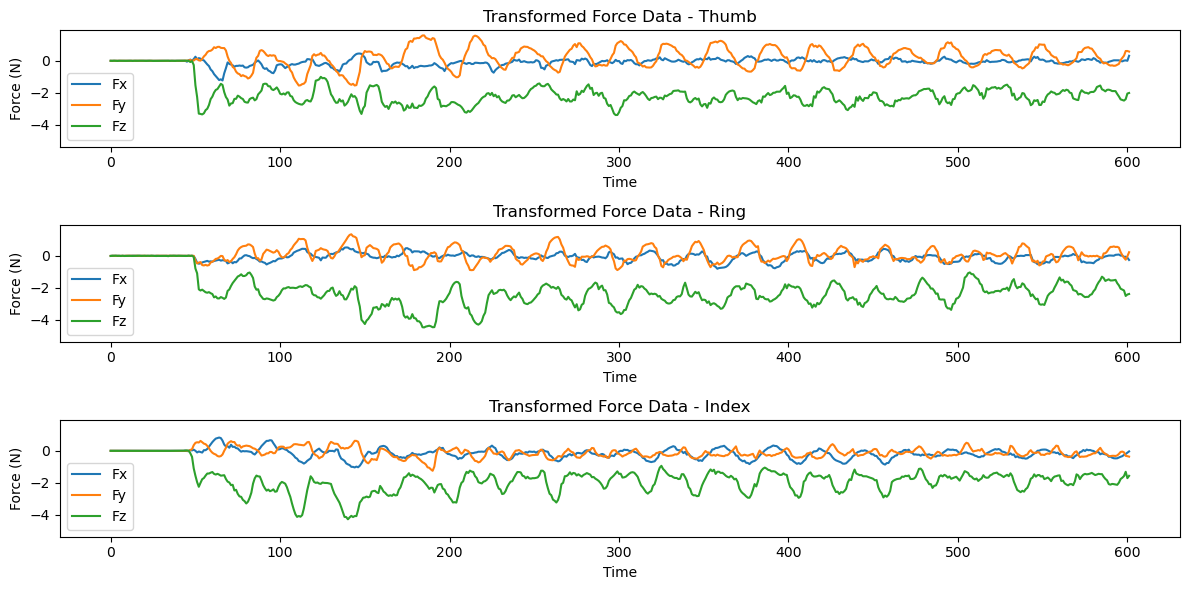

In [518]:
quick_visualization(transformed_data_force, visualize_data='transformed')

## Data Segmentation

Thumb peak regions: 1, Ring peak regions: 1, Index peak regions: 1


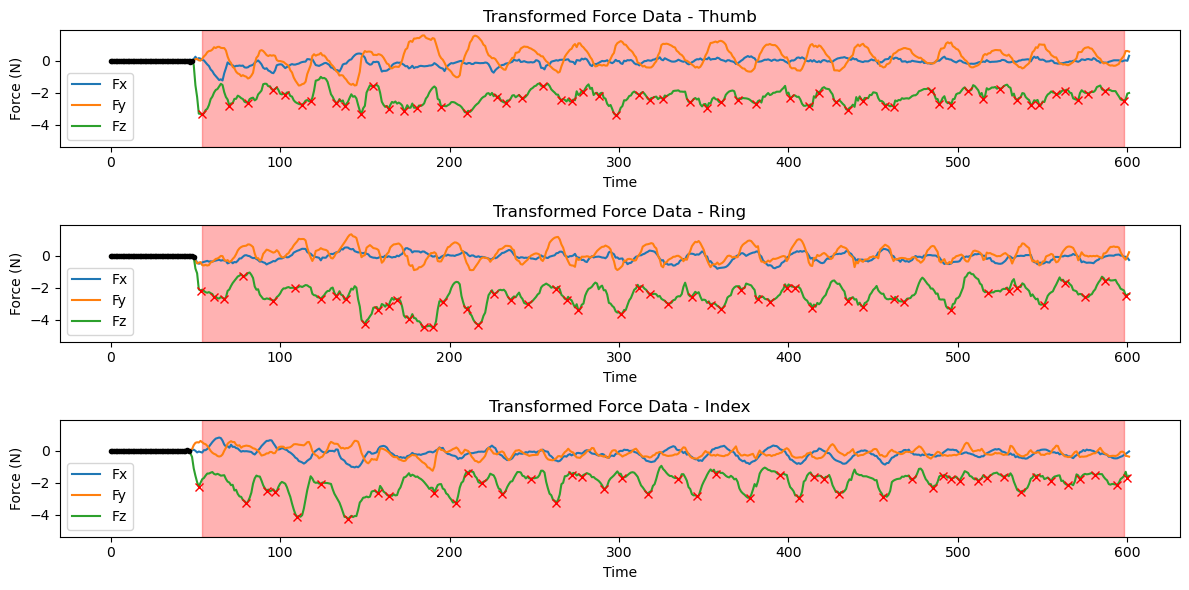

In [519]:
masked_data= mask_calculation(transformed_data_force, data_height=0.5, zero_height=zero_height)

In [520]:
with open(file_dir, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(masked_data)

## Main Analysis

Before clipping, data samples: 545
After clipping, data samples: 545
PC  | Eigenvalue | Variance Ratio
----------------------------------------
PC1   | 1.0963     | 56.31%
PC2   | 0.4390     | 22.55%
PC3   | 0.1923     | 9.87%
PC4   | 0.1107     | 5.68%
PC5   | 0.0474     | 2.44%
PC6   | 0.0377     | 1.93%
PC7   | 0.0175     | 0.90%
PC8   | 0.0042     | 0.22%
PC9   | 0.0020     | 0.10%
----------------------------------------
Sum of eigenvalues: 1.9469



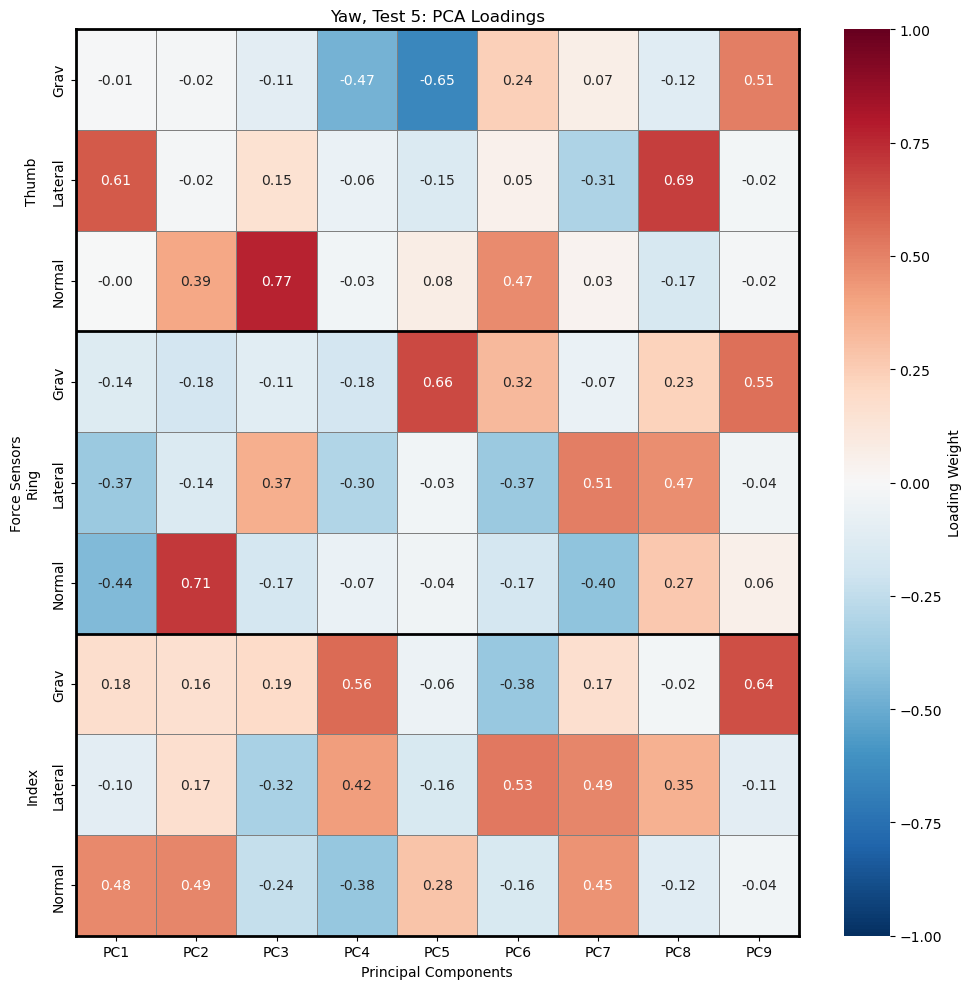

In [521]:
pca_analysis_and_plot(masked_data, transformed_flag=True, visualize=True)